# 6.2 Réplica del efecto de fuga de hablante (diseño controlado)

**Pregunta.** Buena parte de la bibliografía sobre DAIC-WOZ reporta F1 en torno a 0.70-0.90,
mientras que este trabajo, con un protocolo estricto, obtiene F1 ≈ 0.50. ¿A qué se debe esa
distancia? La hipótesis documentada es la **fuga de identidad de hablante**: cuando fragmentos de
un mismo sujeto aparecen simultáneamente en entrenamiento y test, el modelo **reconoce a la
persona** en lugar de aprender marcadores de depresión.

**Diseño (réplica del estudio de referencia).** Se reproduce el procedimiento controlado descrito
en la literatura, que aísla el efecto de forma limpia:

1. Los sujetos se reparten en dos grupos disjuntos: **control** (~80 %) y **objetivo** (~20 %).
2. Las ventanas de cada sujeto del grupo objetivo se dividen **por la mitad**: una mitad constituye
   el **test compartido** y la otra queda disponible para entrenamiento.
3. Se entrenan **dos modelos idénticos** que solo difieren en el conjunto de entrenamiento:

   | Condición | Entrenamiento | Test |
   |---|---|---|
   | **SIN solapamiento** | ventanas del grupo control | mitad del grupo objetivo |
   | **CON solapamiento** | control **+ la otra mitad del grupo objetivo** | **el mismo test** |

**La clave del diseño:** el conjunto de test es **exactamente el mismo** en ambas condiciones —
los mismos sujetos y las mismas ventanas. Lo único que cambia es si el modelo ha visto *otros
fragmentos de esas mismas personas* durante el entrenamiento. Cualquier diferencia de rendimiento
es, por tanto, atribuible **únicamente a la fuga de hablante**.

**Dos representaciones.** El experimento se repite con:
- **Acústicas propias (45)**: media y desviación típica por ventana (las de este trabajo).
- **Embeddings wav2vec2 (768)**: representación profunda preentrenada, del tipo que emplea la
  literatura y de la que se ha documentado que **codifica identidad del hablante**.

Esto permite comprobar no solo *si* existe el efecto, sino **de qué depende**: de la riqueza de la
representación empleada.

## 0. Setup

In [1]:
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_recall_fscore_support, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
OUT = PROJECT_DIR + '/output'
PHQ_THRESHOLD, RANDOM_STATE = 10, 42
P_TARGET = 0.20     # proporcion de sujetos en el grupo objetivo
P_VAL    = 0.20     # proporcion del grupo control reservada para ajustar el umbral

## 1. Carga de las dos representaciones
Ambas proceden del mismo ventaneo (4 s de habla del paciente) y comparten `participant_id`.

In [2]:
# --- A) acusticas propias (45 por ventana). Se EXCLUYEN las variables de pausas:
#         son constantes por sujeto y actuarian como identificador, contaminando el experimento.
seg = pd.read_csv(OUT + '/df_segment_features_vf.csv')
ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')
COLS_AC = [c for c in seg.columns if c.startswith(ACOUSTIC_PREFIXES)]
seg = seg[['participant_id', 'phq8_score'] + COLS_AC].copy()

# --- B) embeddings wav2vec2 (768 por ventana)
w2v = pd.read_csv(OUT + '/df_wav2vec_features.csv')
COLS_W2V = [c for c in w2v.columns if c.startswith('emb_')]
w2v = w2v[['participant_id', 'phq8_score'] + COLS_W2V].copy()

for d in (seg, w2v):
    d['y'] = (d['phq8_score'] >= PHQ_THRESHOLD).astype(int)

print(f"Acústicas propias : {len(seg):>6} ventanas x {len(COLS_AC):>3} variables")
print(f"Embeddings wav2vec: {len(w2v):>6} ventanas x {len(COLS_W2V):>3} variables")
print(f"Sujetos: {seg.participant_id.nunique()} / {w2v.participant_id.nunique()}")

Acústicas propias :  19009 ventanas x  45 variables
Embeddings wav2vec:  19132 ventanas x 768 variables
Sujetos: 186 / 186


## 2. Construcción del diseño controlado (idéntico para ambas representaciones)

In [3]:
def build_design(df, seed=RANDOM_STATE):
    """Devuelve indices: control-train, control-val, objetivo-train(mitad), test compartido(mitad)."""
    rng = np.random.RandomState(seed)
    subj = df.groupby('participant_id')['y'].first()

    # reparto de SUJETOS en control / objetivo, estratificado por etiqueta
    target = []
    for lab in (0, 1):
        s = subj[subj == lab].index.values
        rng.shuffle(s)
        target += list(s[:max(1, int(round(len(s) * P_TARGET)))])
    target = set(target)
    control = [s for s in subj.index if s not in target]

    # dentro del control, una parte de SUJETOS para validacion (ajuste de umbral)
    rng.shuffle(control)
    n_val = max(1, int(round(len(control) * P_VAL)))
    ctrl_val, ctrl_tr = set(control[:n_val]), set(control[n_val:])

    # el grupo objetivo se parte POR LA MITAD DENTRO DE CADA SUJETO
    tgt_train_idx, test_idx = [], []
    for pid, g in df[df.participant_id.isin(target)].groupby('participant_id'):
        i = g.index.values.copy(); rng.shuffle(i)
        mid = len(i) // 2
        test_idx      += list(i[:mid])      # mitad 1 -> TEST COMPARTIDO
        tgt_train_idx += list(i[mid:])      # mitad 2 -> disponible para entrenar
    return (df.index[df.participant_id.isin(ctrl_tr)].values,
            df.index[df.participant_id.isin(ctrl_val)].values,
            np.array(tgt_train_idx), np.array(test_idx), target)


def build_model(kind='rf'):
    """Cabeza adecuada a cada representacion:
       - 'rf'     : Random Forest, para las 45 acusticas (como en el resto del trabajo).
       - 'logreg' : Regresion logistica, cabeza estandar sobre embeddings auto-supervisados.
       (Un RF con max_features='log2' solo evalua ~9 de 768 dimensiones por corte, por lo que
        infrautiliza los embeddings; la comparacion de interes es SIN vs CON solapamiento
        DENTRO de cada representacion, no entre representaciones.)"""
    if kind == 'logreg':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('clf',     LogisticRegression(C=0.1, class_weight='balanced', max_iter=3000)),
        ])
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     RandomForestClassifier(n_estimators=330, max_depth=8,
                                           min_samples_leaf=13, min_samples_split=33,
                                           max_features='log2', class_weight='balanced',
                                           random_state=RANDOM_STATE, n_jobs=-1)),
    ])

def best_thr(y, p):
    ths = np.linspace(0.05, 0.95, 181)
    return ths[int(np.argmax([f1_score(y, (p >= t).astype(int), zero_division=0) for t in ths]))]

def report(y, p, thr):
    yh = (p >= thr).astype(int)
    pr, rc, f, _ = precision_recall_fscore_support(y, yh, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, yh).ravel()
    _, _, bf, _ = precision_recall_fscore_support(y, np.ones(len(y)), average='binary', zero_division=0)
    return dict(AUC=roc_auc_score(y, p), Prec=pr, Rec=rc, F1=f, Acc=accuracy_score(y, yh),
                F1_trivial=bf, TP=tp, FP=fp, FN=fn, TN=tn)

## 3. Ejecución del experimento
Para cada representación se entrenan dos modelos idénticos que solo difieren en si las ventanas
sobrantes del grupo objetivo entran o no en el entrenamiento. **El test es el mismo en ambos.**

In [4]:
def run(df, cols, nombre, kind='rf'):
    ctrl_tr, ctrl_val, tgt_tr, test, target = build_design(df)
    Xva, yva = df.loc[ctrl_val, cols], df.loc[ctrl_val, 'y']
    Xte, yte = df.loc[test, cols],     df.loc[test, 'y']

    print(f"--- {nombre} ---")
    print(f"  sujetos: control {df.loc[ctrl_tr,'participant_id'].nunique()} (+{len(set(df.loc[ctrl_val,'participant_id']))} val) "
          f"| objetivo {len(target)}")
    print(f"  ventanas: control-train {len(ctrl_tr)} | objetivo-train {len(tgt_tr)} | TEST compartido {len(test)}")

    res = {}
    for cond, idx_tr in [('SIN solapamiento', ctrl_tr),
                         ('CON solapamiento', np.concatenate([ctrl_tr, tgt_tr]))]:
        m = build_model(kind).fit(df.loc[idx_tr, cols], df.loc[idx_tr, 'y'])
        thr = best_thr(yva.values, m.predict_proba(Xva)[:, 1])
        r = report(yte.values, m.predict_proba(Xte)[:, 1], thr)
        r['thr'] = round(float(thr), 2)
        res[cond] = r
        print(f"  {cond}: AUC {r['AUC']:.3f} | F1 {r['F1']:.3f} | Prec {r['Prec']:.3f} | Rec {r['Rec']:.3f}")
    print()
    return res

res_ac  = run(seg, COLS_AC,  'ACÚSTICAS PROPIAS (45, media+desv. por ventana) — Random Forest', 'rf')
res_w2v = run(w2v, COLS_W2V, 'EMBEDDINGS wav2vec2 (768, repr. profunda) — Regresión logística', 'logreg')

--- ACÚSTICAS PROPIAS (45, media+desv. por ventana) — Random Forest ---
  sujetos: control 119 (+30 val) | objetivo 37
  ventanas: control-train 12188 | objetivo-train 1876 | TEST compartido 1857
  SIN solapamiento: AUC 0.567 | F1 0.464 | Prec 0.316 | Rec 0.876
  CON solapamiento: AUC 0.749 | F1 0.522 | Prec 0.365 | Rec 0.915

--- EMBEDDINGS wav2vec2 (768, repr. profunda) — Regresión logística ---
  sujetos: control 119 (+30 val) | objetivo 37
  ventanas: control-train 12262 | objetivo-train 1885 | TEST compartido 1869
  SIN solapamiento: AUC 0.540 | F1 0.452 | Prec 0.295 | Rec 0.974
  CON solapamiento: AUC 0.713 | F1 0.457 | Prec 0.297 | Rec 0.987



## 4. Resultados

In [5]:
filas = {}
for rep, res in [('Acústicas propias (45)', res_ac), ('Embeddings wav2vec2 (768)', res_w2v)]:
    for cond, r in res.items():
        filas[f'{rep} — {cond}'] = r
tabla = pd.DataFrame(filas).T[['thr','AUC','Prec','Rec','F1','Acc','F1_trivial','TP','FP','FN','TN']]
for c in ['AUC','Prec','Rec','F1','Acc','F1_trivial']: tabla[c] = tabla[c].astype(float).round(3)
print('Mismo test en cada bloque. Lo único que cambia: si el modelo vio OTRAS ventanas de esos mismos sujetos.\n')
tabla

Mismo test en cada bloque. Lo único que cambia: si el modelo vio OTRAS ventanas de esos mismos sujetos.



,thr,AUC,Prec,Rec,F1,Acc,F1_trivial,TP,FP,FN,TN
Acústicas propias (45) — SIN solapamiento,0.37,0.567,0.316,0.876,0.464,0.421,0.445,466.0,1010.0,66.0,315.0
Acústicas propias (45) — CON solapamiento,0.39,0.749,0.365,0.915,0.522,0.520,0.445,487.0,847.0,45.0,478.0
Embeddings wav2vec2 (768) — SIN solapamiento,0.05,0.540,0.295,0.974,0.452,0.325,0.445,521.0,1248.0,14.0,86.0
Embeddings wav2vec2 (768) — CON solapamiento,0.05,0.713,0.297,0.987,0.457,0.329,0.445,528.0,1248.0,7.0,86.0


In [6]:
print('EFECTO DE LA FUGA DE HABLANTE (test idéntico en ambas condiciones)\n')
for rep, res in [('Acústicas propias (45)  ', res_ac), ('Embeddings wav2vec2 (768)', res_w2v)]:
    a, b = res['SIN solapamiento'], res['CON solapamiento']
    print(f"{rep} :  AUC {a['AUC']:.3f} -> {b['AUC']:.3f}  ({b['AUC']-a['AUC']:+.3f})"
          f"   |  F1 {a['F1']:.3f} -> {b['F1']:.3f}  ({b['F1']-a['F1']:+.3f})")
print('\nReferencia del estudio controlado (representaciones profundas): ~+0.20 F1')

EFECTO DE LA FUGA DE HABLANTE (test idéntico en ambas condiciones)

Acústicas propias (45)   :  AUC 0.567 -> 0.749  (+0.182)   |  F1 0.464 -> 0.522  (+0.058)
Embeddings wav2vec2 (768) :  AUC 0.540 -> 0.713  (+0.173)   |  F1 0.452 -> 0.457  (+0.005)

Referencia del estudio controlado (representaciones profundas): ~+0.20 F1


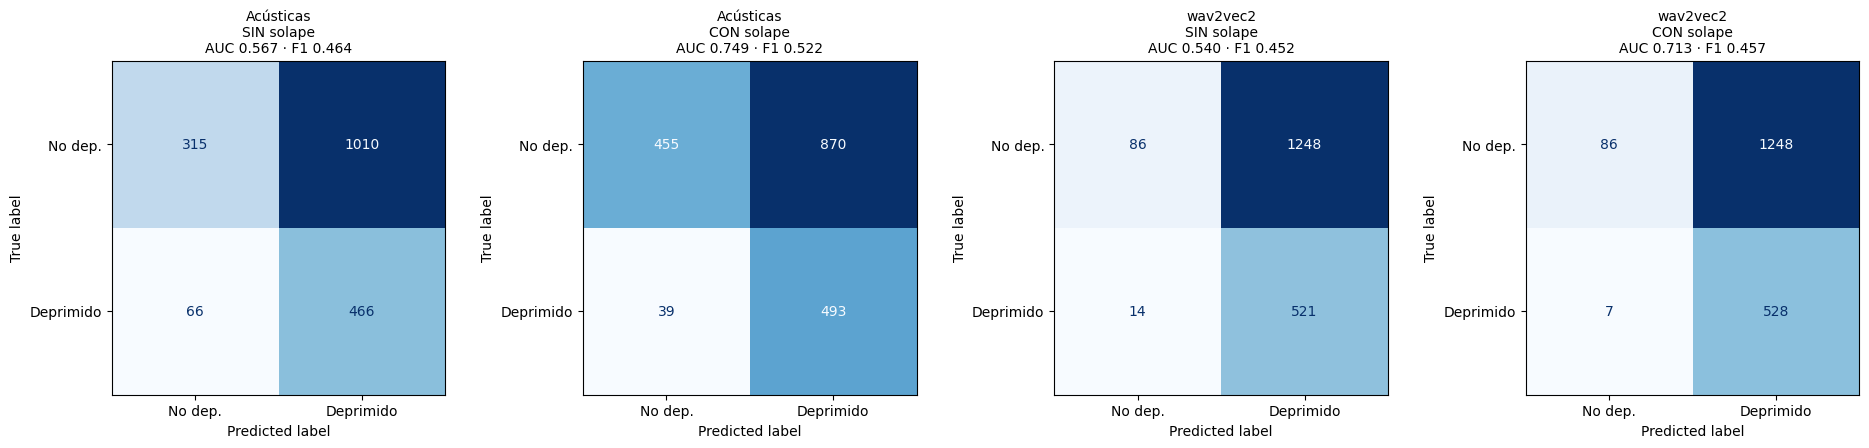

In [7]:
# Matrices de confusion en CONTEO NETO de casos
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
paneles = []
for rep, res, df_, cols, kind in [('Acústicas', res_ac, seg, COLS_AC, 'rf'),
                                  ('wav2vec2',  res_w2v, w2v, COLS_W2V, 'logreg')]:
    ctrl_tr, ctrl_val, tgt_tr, test, _ = build_design(df_)
    for cond, idx_tr in [('SIN solape', ctrl_tr), ('CON solape', np.concatenate([ctrl_tr, tgt_tr]))]:
        m = build_model(kind).fit(df_.loc[idx_tr, cols], df_.loc[idx_tr, 'y'])
        p = m.predict_proba(df_.loc[test, cols])[:, 1]
        key = 'SIN solapamiento' if cond == 'SIN solape' else 'CON solapamiento'
        paneles.append((f'{rep}\n{cond}', res[key], df_.loc[test, 'y'].values, p))

for ax, (titulo, r, y, p) in zip(axes, paneles):
    ConfusionMatrixDisplay.from_predictions(y, (p >= r['thr']).astype(int),
        display_labels=['No dep.', 'Deprimido'], colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(f"{titulo}\nAUC {r['AUC']:.3f} · F1 {r['F1']:.3f}", fontsize=10)
plt.tight_layout(); plt.show()

## 5. Lectura

El diseño garantiza que **el conjunto de test es idéntico** en cada par de condiciones: mismos
sujetos, mismas ventanas. La única diferencia es si el modelo ha visto *otros fragmentos de esas
mismas personas* al entrenar. Por tanto, toda diferencia de rendimiento es atribuible a la **fuga
de identidad de hablante**, y no a la dificultad del conjunto de test.

Lo relevante no es solo la magnitud del efecto, sino **su dependencia de la representación**:

- Si el efecto es pequeño con las **acústicas propias** y grande con los **embeddings wav2vec2**,
  queda demostrado que la fuga requiere representaciones capaces de codificar identidad vocal.
  Las variables empleadas en este trabajo (media y desviación típica por ventana) son demasiado
  gruesas para ello, mientras que las representaciones profundas —las habituales en la
  bibliografía— sí la codifican.
- Esto proporciona una explicación **verificada experimentalmente** de la distancia entre los
  resultados honestos de este trabajo y las cifras publicadas, sin necesidad de suponer que el
  modelo aquí desarrollado sea inferior.

> El rendimiento que se reporta como resultado del sistema es siempre el obtenido **sin
> solapamiento** y con partición por sujeto.

> **Sobre qué métrica refleja el efecto.** En este experimento la fuga se manifiesta sobre todo en
> el **AUC** (capacidad de ordenación). El F1 apenas se mueve porque ambos modelos operan en un
> punto degenerado —recall cercano a 1 con precisión próxima a la prevalencia—, de modo que el
> umbral no puede traducir la mejora de ordenación en mejor clasificación. Por ello el efecto se
> reporta principalmente en AUC, indicando explícitamente esta limitación.